# 微积分

---

## 练习2.4.1

绘制函数$\displaystyle y = f(x) = x^3 - \frac{1}{x}$和其在$x = 1$处切线的图像。

### &emsp;解答

前向 f(x) 一致性  : True
切线 一致性       : True


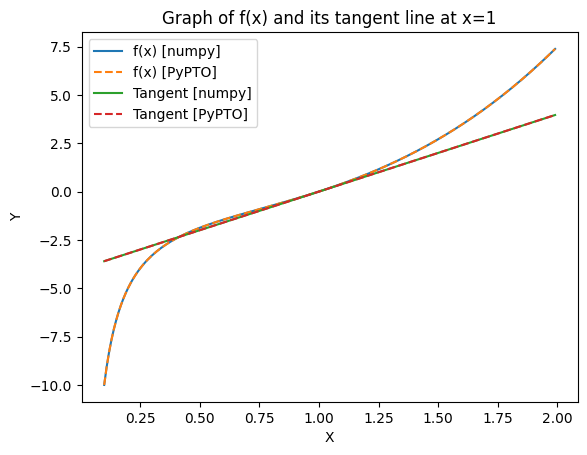

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pypto

device = "npu:0"  # sim 模式可改为 "cpu"

# Kernel 1: f(x) = x^3 - 1/x
@pypto.frontend.jit
def cubic_recip_kernel(
    x: pypto.Tensor([1, 190], pypto.DT_FP32),
    out: pypto.Tensor([1, 190], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(1, 128)
    out[:] = x ** 3 - 1.0 / x


# Kernel 2: 切线 y = grad * (x - point) + f(point)
@pypto.frontend.jit
def tangent_line_kernel(
    x: pypto.Tensor([1, 190], pypto.DT_FP32),
    grad: pypto.Tensor([1, 1], pypto.DT_FP32),
    point: pypto.Tensor([1, 1], pypto.DT_FP32),
    f_at_point: pypto.Tensor([1, 1], pypto.DT_FP32),
    out: pypto.Tensor([1, 190], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(1, 128)
    out[:] = grad * (x - point) + f_at_point


# ===== PyPTO 计算 =====
# 用前向差分在 NPU 上求 x=1 处的导数（直接复用 cubic_recip_kernel）
h = 1e-4
x_p = torch.tensor([[1.0]], dtype=torch.float32, device=device)
x_ph = torch.tensor([[1.0 + h]], dtype=torch.float32, device=device)
f_p = torch.empty(1, 1, dtype=torch.float32, device=device)
f_ph = torch.empty(1, 1, dtype=torch.float32, device=device)
cubic_recip_kernel(x_p, f_p)
cubic_recip_kernel(x_ph, f_ph)
grad = (f_ph - f_p) / h

# 在 NPU 上计算主曲线与切线
N = 190
x = torch.arange(0.1, 2.0, 0.01, dtype=torch.float32, device=device).reshape(1, N)
y = torch.empty(1, N, dtype=torch.float32, device=device)
y_tangent = torch.empty(1, N, dtype=torch.float32, device=device)
cubic_recip_kernel(x, y)
tangent_line_kernel(x, grad, x_p, f_p, y_tangent)

# 切回 host 端（matplotlib 必须 host 端）
x_np = x.reshape(-1).cpu().numpy()
y_pypto = y.reshape(-1).cpu().numpy()
y_tangent_pypto = y_tangent.reshape(-1).cpu().numpy()

# ===== numpy 参考 =====
y_np = x_np ** 3 - 1.0 / x_np
y_tangent_np = 4.0 * (x_np - 1.0) + 0.0  # f'(1)=4, f(1)=0

# ===== 互验 =====
print(f"前向 f(x) 一致性  : {np.allclose(y_pypto, y_np, rtol=1e-3, atol=1e-3)}")
print(f"切线 一致性       : {np.allclose(y_tangent_pypto, y_tangent_np, rtol=1e-3, atol=1e-3)}")

# 绘图
plt.plot(x_np, y_np, label='f(x) [numpy]')
plt.plot(x_np, y_pypto, '--', label='f(x) [PyPTO]')
plt.plot(x_np, y_tangent_np, label='Tangent [numpy]')
plt.plot(x_np, y_tangent_pypto, '--', label='Tangent [PyPTO]')
plt.legend()
plt.title('Graph of f(x) and its tangent line at x=1')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

---

## 练习2.4.2

求函数$f(\mathbf{x}) = 3x_1^2 + 5e^{x_2}$的梯度。

### &emsp;解答

&emsp;&emsp;根据梯度的定义：
$$
\frac{\partial{f(x)}}{\partial{x_1}} = 6 x_1 \\
\frac{\partial{f(x)}}{\partial{x_2}} = 5 e^{x_2}
$$


$$
则：\frac{\partial{f(x)}}{\partial x} = (6 x_1, 5 e^{x_2})
$$

&emsp;&emsp;PyPTO 不内建自动微分，下面的实现用 PyTorch `autograd` 作为"自动微分"参考，同时把前向与解析梯度分别写进 2 个 PyPTO kernel 在 NPU 上执行，最后让两条路径互验。

In [ ]:
import numpy as np
import torch
import pypto

device = "npu:0"

# Kernel 1: 前向 y = 3*x0^2 + 5*exp(x1)
@pypto.frontend.jit
def polyexp_forward_kernel(
    x0: pypto.Tensor([1, 1], pypto.DT_FP32),
    x1: pypto.Tensor([1, 1], pypto.DT_FP32),
    out: pypto.Tensor([1, 1], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(1, 8)
    out[:] = 3.0 * x0 ** 2 + 5.0 * pypto.exp(x1)


# Kernel 2: 解析梯度 grad = [6*x0, 5*exp(x1)]
@pypto.frontend.jit
def polyexp_grad_kernel(
    x0: pypto.Tensor([1, 1], pypto.DT_FP32),
    x1: pypto.Tensor([1, 1], pypto.DT_FP32),
    out_g0: pypto.Tensor([1, 1], pypto.DT_FP32),
    out_g1: pypto.Tensor([1, 1], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(1, 8)
    out_g0[:] = 6.0 * x0
    out_g1[:] = 5.0 * pypto.exp(x1)


# ===== PyTorch autograd 参考 =====
x_torch = torch.arange(2.0, requires_grad=True)
y_torch = 3 * x_torch[0] ** 2 + 5 * torch.exp(x_torch[1])
y_torch.backward()
y_torch_val = y_torch.item()
grad_torch = x_torch.grad.cpu().numpy()

# ===== PyPTO 计算 =====
x0_t = torch.tensor([[0.0]], dtype=torch.float32, device=device)
x1_t = torch.tensor([[1.0]], dtype=torch.float32, device=device)
out_y = torch.empty(1, 1, dtype=torch.float32, device=device)
out_g0 = torch.empty(1, 1, dtype=torch.float32, device=device)
out_g1 = torch.empty(1, 1, dtype=torch.float32, device=device)
polyexp_forward_kernel(x0_t, x1_t, out_y)
polyexp_grad_kernel(x0_t, x1_t, out_g0, out_g1)
y_pypto = out_y.reshape(-1).cpu().item()
grad_pypto = torch.cat([out_g0, out_g1], dim=-1).reshape(-1).cpu().numpy()

# ===== 互验 =====
print(f"PyTorch y = {y_torch_val:.6f},  PyPTO y = {y_pypto:.6f}")
print(f"PyTorch 梯度 = {grad_torch},  PyPTO 梯度 = {grad_pypto}")
print(f"前向一致性   : {np.allclose(y_pypto, y_torch_val, rtol=1e-3, atol=1e-3)}")
print(f"梯度一致性   : {np.allclose(grad_pypto, grad_torch, rtol=1e-3, atol=1e-3)}")

PyTorch y = 13.591409,  PyPTO y = 13.591409
PyTorch 梯度 = [ 0.       13.591409],  PyPTO 梯度 = [ 0.       13.591409]
前向一致性   : True
梯度一致性   : True


---

## 练习2.4.3

函数$f(\mathbf{x}) = \|\mathbf{x}\|_2$ 的梯度是什么？

### &emsp;解答

&emsp;&emsp;根据2-范数的定义，可得：
$$
f(x) = \|x\|_2 = \sqrt{x_1^2 + x_2^2 + \cdots + x_n^2}
$$

&emsp;&emsp;函数$f(x)$的梯度：
$$
\begin{aligned}
\frac{\partial{f}}{\partial{x}} 
&= \left( \frac{\partial{f}}{\partial{x_1}}, \frac{\partial{f}}{\partial{x_2}}, \cdots, \frac{\partial{f}}{\partial{x_n}}  \right) \\
&= \left(\frac{1}{2} \cdot 2 x_1 \cdot \left( \sum_{i=1}^n x_i^2 \right)^{-\frac{1}{2}}, \frac{1}{2} \cdot 2 x_2 \cdot \left( \sum_{i=1}^n x_i^2 \right)^{-\frac{1}{2}}, \cdots, \frac{1}{2} \cdot 2 x_n \cdot \left( \sum_{i=1}^n x_i^2 \right)^{-\frac{1}{2}} \right) \\
&= \left( \frac{x_1}{\sqrt{\sum_{i=1}^n x_i^2}},  \frac{x_2}{\sqrt{\sum_{i=1}^n x_i^2}}, \cdots, \frac{x_n}{\sqrt{\sum_{i=1}^n x_i^2}} \right) \\
&= \left( \frac{x_1}{\|x\|_2}, \frac{x_2}{\|x\|_2}, \cdots, \frac{x_n}{\|x\|_2} \right) \\
&= \frac{x}{\|x\|_2}
\end{aligned}
$$

&emsp;&emsp;PyTorch `autograd` 路径 + PyPTO kernel 路径互验：前向与梯度分别写成 2 个 kernel，梯度 kernel 复用前向算出的 $y=\|x\|_2$。

In [3]:
import numpy as np
import torch
import pypto

device = "npu:0"

# Kernel 1: 前向 y = ||x||_2
@pypto.frontend.jit
def l2norm_forward_kernel(
    x: pypto.Tensor([1, 4], pypto.DT_FP32),
    out: pypto.Tensor([1, 1], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(1, 8)
    out[:] = pypto.sqrt(pypto.sum(x ** 2, dim=-1, keepdim=True))


# Kernel 2: 解析梯度 grad = x / ||x||_2
@pypto.frontend.jit
def l2norm_grad_kernel(
    x: pypto.Tensor([1, 4], pypto.DT_FP32),
    y: pypto.Tensor([1, 1], pypto.DT_FP32),
    out: pypto.Tensor([1, 4], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(1, 8)
    out[:] = x / y


# ===== PyTorch autograd 参考 =====
x_torch = torch.arange(4.0, requires_grad=True)
y_torch = torch.dot(x_torch, x_torch).sqrt()
y_torch.backward()
y_torch_val = y_torch.item()
grad_torch = x_torch.grad.cpu().numpy()

# ===== PyPTO 计算 =====
x = torch.arange(4.0, dtype=torch.float32, device=device).reshape(1, 4)
out_y = torch.empty(1, 1, dtype=torch.float32, device=device)
out_grad = torch.empty(1, 4, dtype=torch.float32, device=device)
l2norm_forward_kernel(x, out_y)
l2norm_grad_kernel(x, out_y, out_grad)
y_pypto = out_y.reshape(-1).cpu().item()
grad_pypto = out_grad.reshape(-1).cpu().numpy()

# ===== 互验 =====
print(f"PyTorch y = {y_torch_val:.6f},  PyPTO y = {y_pypto:.6f}")
print(f"PyTorch 梯度 = {grad_torch},  PyPTO 梯度 = {grad_pypto}")
print(f"前向一致性   : {np.allclose(y_pypto, y_torch_val, rtol=1e-3, atol=1e-3)}")
print(f"梯度一致性   : {np.allclose(grad_pypto, grad_torch, rtol=1e-3, atol=1e-3)}")

PyTorch y = 3.741657,  PyPTO y = 3.741657
PyTorch 梯度 = [0.         0.26726124 0.5345225  0.8017837 ],  PyPTO 梯度 = [0.         0.26726124 0.5345225  0.8017837 ]
前向一致性   : True
梯度一致性   : True


---

## 练习2.4.4

尝试写出函数$u = f(x, y, z)$，其中$x = x(a, b)$，$y = y(a, b)$，$z = z(a, b)$的链式法则。

### &emsp;解答

&emsp;&emsp;根据链式求导法则，可得：
$$
\frac{\partial u}{\partial a}=\frac{\partial u}{\partial x} \frac{\partial x}{\partial a}+\frac{\partial u}{\partial y} \frac{\partial y}{\partial a}+\frac{\partial u}{\partial z} \frac{\partial z}{\partial a} \\
\frac{\partial u}{\partial b}=\frac{\partial u}{\partial x} \frac{\partial x}{\partial b}+\frac{\partial u}{\partial y} \frac{\partial y}{\partial b}+\frac{\partial u}{\partial z} \frac{\partial z}{\partial b}
$$